## Objective
1. Load full finetuned BERT model for sentiment analysis
2. Load full finetuned BERT model for sarcasm detection
3. Obtain predictions of sentiment for test data
4. Feed test data to sarcasm detection BERT model
5. Swap the predictions for all reviews predicted as sarcastic
6. Evaluate this method of sentiment analysis with sarcasm detection

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

Load the Amazon reviews test data

In [2]:
test_df = pd.read_csv("test.csv")
print(test_df.shape)

# Convert string labels to binary labels
label_to_id_map = {"negative": 0, "positive": 1}
id_to_label_map = {0: "negative", 1: "positive"}
test_df["label"] = test_df["label"].map(label_to_id_map)
print(test_df.head())

(7484, 2)
   label                                             review
0      0  Howlingly Horrible: This was one of the most e...
1      1  Shocking for its time: This movie about a bunc...
2      1  Bowie keeps on getting better and better: Davi...
3      1  Meryl Streep is Great: Great movie for it's ti...
4      0  Not what I expected: I purchased this for my g...


Define metrics

In [3]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

Load the BERT models for sentiment analysis and sarcasm detection

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1_name = "cxl1020/full-finetuned-bert-for-Amazon-sentiment-analysis"
model1 = AutoModelForSequenceClassification.from_pretrained(model1_name)
tokenizer = AutoTokenizer.from_pretrained(model1_name)

model2_name = "cxl1020/full-finetuned-bert-for-sarcasm-detection"
model2 = AutoModelForSequenceClassification.from_pretrained(model2_name).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Tokenize test data

In [5]:
def tokenize_function_current(text):
  return tokenizer(text["review"], padding="max_length", truncation=True)

# Convert test_df to Dataset and tokenize
test_dataset_for_current_model = Dataset.from_pandas(test_df.copy())
tokenized_test_df_current = test_dataset_for_current_model.map(tokenize_function_current, batched=True)

Map:   0%|          | 0/7484 [00:00<?, ? examples/s]

Evaluate original performance of sentiment analysis BERT model by itself

In [6]:
eval_args = TrainingArguments(
    output_dir=f'./eval_results/{model1_name.replace("/", "-")}',
    do_train=False,  # don't train the model
    do_eval=True,  # evaluate the model
    per_device_eval_batch_size=32,
    report_to='none',
    disable_tqdm=True
)

trainer = Trainer(
    model=model1,
    args=eval_args,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    eval_dataset=tokenized_test_df_current
)

/tmp/ipython-input-1724453689.py:10: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [7]:
preds_outputs = trainer.predict(tokenized_test_df_current)
evaluation_metrics = preds_outputs.metrics
print(evaluation_metrics)

{'test_loss': 0.13237616419792175, 'test_model_preparation_time': 0.0029, 'test_accuracy': 0.9533671833244255, 'test_f1': 0.9533576376112795, 'test_precision': 0.9534588189568385, 'test_recall': 0.9533671833244255, 'test_runtime': 235.0448, 'test_samples_per_second': 31.841, 'test_steps_per_second': 0.996}


              precision    recall  f1-score   support

    negative       0.96      0.94      0.95      3670
    positive       0.95      0.96      0.95      3814

    accuracy                           0.95      7484
   macro avg       0.95      0.95      0.95      7484
weighted avg       0.95      0.95      0.95      7484



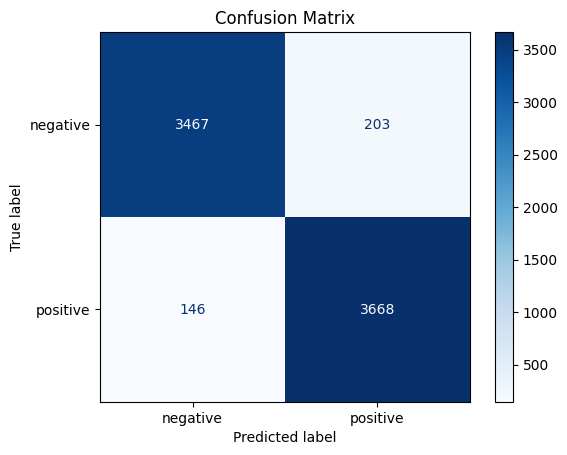

In [8]:
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = preds_outputs.label_ids
print(classification_report(y_true, y_preds, zero_division=0, target_names=id_to_label_map.values()))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id_to_label_map.values()))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


### Sentiment analysis with sarcasm detection

Obtain the predictions (sarcastic or not) for the Amazon reviews test data

In [10]:
reviews = test_df["review"]
sarcastic_id_to_label_map = {0: "not sarcastic", 1: "sarcastic"}
predictions = [] # contains prediction for whether the review is sarcastic or not

for text in reviews:
    tokenized_reviews = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    tokenized_reviews = {name: tensor.to(device) for name, tensor in tokenized_reviews.items()}
    outputs = model2(**tokenized_reviews)
    predictions.append(torch.argmax(outputs.logits, axis=1))


In [11]:
extracted_predictions = [p.item() for p in predictions]

results = pd.DataFrame({
    'review': reviews,
    'predictions': extracted_predictions,
    'y_preds': y_preds,
    'y_true': y_true
})

print(results['predictions'].value_counts())
print(results.head())

predictions
0    7399
1      85
Name: count, dtype: int64
                                              review  predictions  y_preds  \
0  Howlingly Horrible: This was one of the most e...            0        0   
1  Shocking for its time: This movie about a bunc...            0        1   
2  Bowie keeps on getting better and better: Davi...            0        1   
3  Meryl Streep is Great: Great movie for it's ti...            0        1   
4  Not what I expected: I purchased this for my g...            0        0   

   y_true  
0       0  
1       1  
2       1  
3       1  
4       0  


Edit the sentiment prediction based on sarcasm prediction of the test data

In [12]:
new_y_preds = results['y_preds'].copy()

for index in range(len(results)):
    # If the review is predicted as sarcastic (1),
    # we invert the sentiment prediction from the sentiment model.
    if results.loc[index, 'predictions'] == 1: # if review is sarcastic
        if results.loc[index, 'y_preds'] == 0:
            new_y_preds[index] = 1
        else:
            new_y_preds[index] = 0

In [13]:
num_differences = (y_preds != new_y_preds).sum()
print(f"Number of sentiment predictions changed due to sarcasm adjustment: {num_differences}")

Number of sentiment predictions changed due to sarcasm adjustment: 85


In [23]:
# Examine the reviews that are predicted as sarcastic
boolean_list = (y_preds != new_y_preds)
indices = [i for i, val in enumerate(boolean_list) if val]
reviews_with_corrected_prediction = reviews.loc[indices]
for i in range(5):
  print(f"Review {i} predicted as sarcastic: {reviews_with_corrected_prediction.iloc[i]}")
  print("-" * 50)

Review 0 predicted as sarcastic: Sandisk 8 gig black: Bought two units and after a few months one stopped working. Could get no info from the unit it was dead. Contacted Sandisk and ask for quick replacement. Offered to prepay to secure item would be shipped quick. Was told I did not need this. Item was bad and would be replaced with in a few days. After waiting a full month, I had to phone the Co on Ca. Manager told me the order had not been shipped and this some times happens. Had phoned the supply house in another state and player would be shipped.Worse customer support I have seen. Would not buy another unit from this Co. Manager I talked with sounded like a brain dead stoner. Might be why orders get lost.Order with caution and if you require replacement, prepare to follow up daily.
--------------------------------------------------
Review 1 predicted as sarcastic: just what I needed: Good materials , excelllen t work done with these, good box, all colors needed in here, a must hav

Evaluate the sentiment analysis performance based on newly updated sentiment predictions

              precision    recall  f1-score   support

    negative       0.95      0.93      0.94      3670
    positive       0.94      0.95      0.95      3814

    accuracy                           0.94      7484
   macro avg       0.94      0.94      0.94      7484
weighted avg       0.94      0.94      0.94      7484



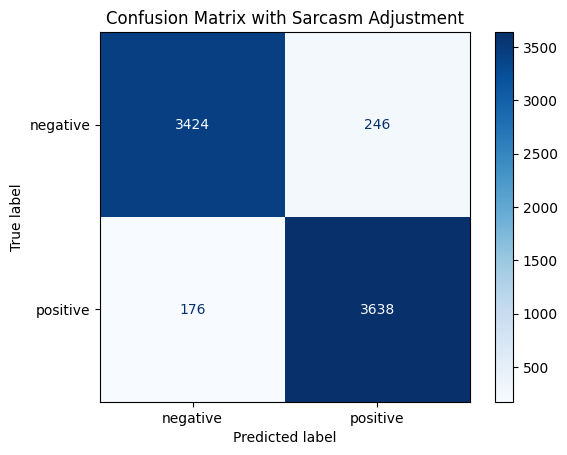

In [24]:
# Now use the new_y_preds for evaluation
f1 = f1_score(y_true, new_y_preds, average='weighted')
acc = accuracy_score(y_true, new_y_preds)
precision = precision_score(y_true, new_y_preds, average='weighted')
recall = recall_score(y_true, new_y_preds, average='weighted')

print(classification_report(y_true, new_y_preds, zero_division=0, target_names=id_to_label_map.values()))

# Plot confusion matrix
cm = confusion_matrix(y_true, new_y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id_to_label_map.values()))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix with Sarcasm Adjustment')
plt.show()